In [1]:
import numpy as np
import matplotlib.pyplot as plt

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux

from few.trajectory.resonancehandler import ResonanceHandler

from multispline.spline import CubicSpline

from few.waveform import FastKerrEccentricEquatorialFlux

In [2]:
# Load the data for the jumps on the resonance surface (a=0.9, x=1)
jump_data = np.loadtxt("/Users/niels/Downloads/resonance-a09_x1_n1k2m-2.csv", delimiter=",")
jump_E = CubicSpline(jump_data[:,1], jump_data[:,2])
jump_L = CubicSpline(jump_data[:,1], jump_data[:,3])
jump_Q = CubicSpline(jump_data[:,1], jump_data[:,4])

In [3]:
def res_jumps_ELQ_n1k2m_2(a,e,x):
    return jump_E(e), jump_L(e), jump_Q(e)

In [4]:
def Omega_phi_3rd_body(a,p,e,x):
    return 50**(-3/2)

The resonance surface is defined by 

$$\kappa_r\Omega_r + \kappa_\theta\Omega_\theta + \kappa_\phi \Omega_\phi + \kappa_f f = 0$$

where $f\equiv f(a,p,e,x)$

In [5]:
res = ResonanceHandler(1,2,-2, 0, res_jumps_ELQ_n1k2m_2)

# Below use the user defined additional function
#res = ResonanceHandler(1,2,-2, 1, res_jumps_ELQ_n1k2m_2, Omega_phi_3rd_body)

In [6]:
# You can also instantiate this as EMRIInspiral(func="KerrEccEqFlux") to save an import.
traj_model_res = EMRIInspiral(func=KerrEccEqFlux, resonance_handler=res, flux_output_convention="ELQ")
traj_model = EMRIInspiral(func=KerrEccEqFlux, flux_output_convention="ELQ")

In [7]:
m1 = 1e6
m2 = 1e2
a = 0.9  # This model supports a spinning primary compact object
p0 = 10.0
e0 = 0.8
xI0 = 1.0  # +1 for prograde, -1 for retrograde inspirals

T = 1  # duration of trajectory in years (as defined by few.utils.constants.YRSID_SI)

traj_pars = [m1, m2, a, p0, e0, xI0]

In [8]:
new_T = np.linspace(0,1.73611189e+07,10000)

In [ ]:
t, p, e, xI, Phi_phi, Phi_theta, Phi_r = traj_model(*traj_pars, T=T, upsample=True, new_t=new_T)
tRes, pRes, eRes, xIRes, Phi_phiRes, Phi_thetaRes, Phi_rRes = traj_model_res(*traj_pars, T=T, upsample=True, new_t=new_T)


fig, axes = plt.subplots(2, 3)
plt.subplots_adjust(wspace=0.35)
fig.set_size_inches(14, 8)
axes = axes.ravel()

ylabels = [r"$e$", r"$p$", r"$e$", r"$\Phi_\phi$", r"$\Phi_\theta$", r"$\Phi_r$"]
xlabels = [r"$p$", r"$t$", r"$t$", r"$t$", r"$t$", r"$t$"]
ys = [eRes, pRes, eRes, Phi_phiRes, Phi_thetaRes, Phi_rRes]
xs = [pRes, tRes, tRes, tRes, tRes, tRes]

for i, (ax, x, y, xlab, ylab) in enumerate(zip(axes, xs, ys, xlabels, ylabels)):
    ax.plot(x, y)
    ax.set_xlabel(xlab, fontsize=16)
    ax.set_ylabel(ylab, fontsize=16)

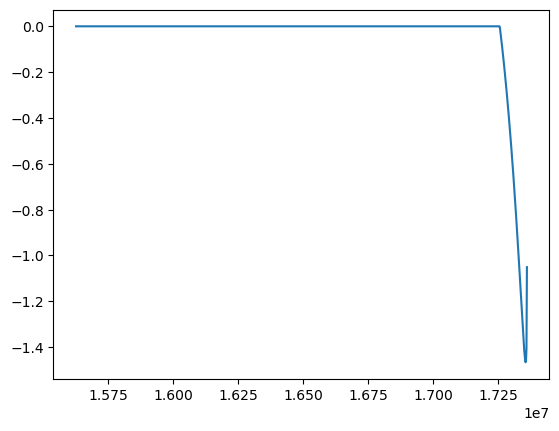

In [22]:
plt.plot(t[9000:],(Phi_phi-Phi_phiRes)[9000:])

In [37]:
wav = FastKerrEccentricEquatorialFlux(inspiral_kwargs={'func':KerrEccEqFlux,'flux_output_convention':"ELQ"})

In [ ]:
wav_res = FastKerrEccentricEquatorialFlux(inspiral_kwargs={'func':KerrEccEqFlux,'resonance_handler':res, 'flux_output_convention':"ELQ"})

In [ ]:
waveform = wav(*traj_pars, dt = 10, T=T,theta=0, phi=0)

In [ ]:
waveform_res = wav_res(*traj_pars, dt = 10, T=T,theta=0, phi=0)

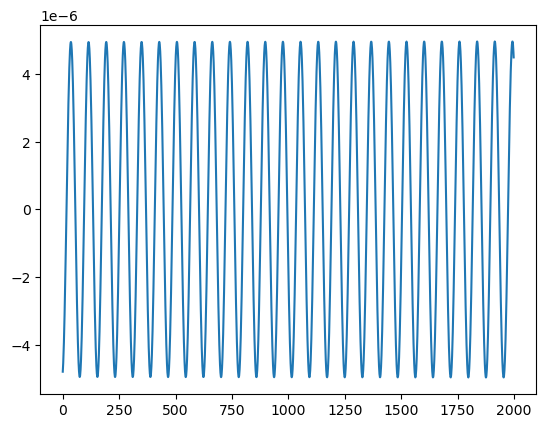

In [59]:
plt.plot(waveform[:2000].real-waveform_res[:2000].real)

In [ ]:
#Why is there any difference in the plot above when the inspirals are the same until the resonance is reached

In [68]:
len(waveform)

1736112

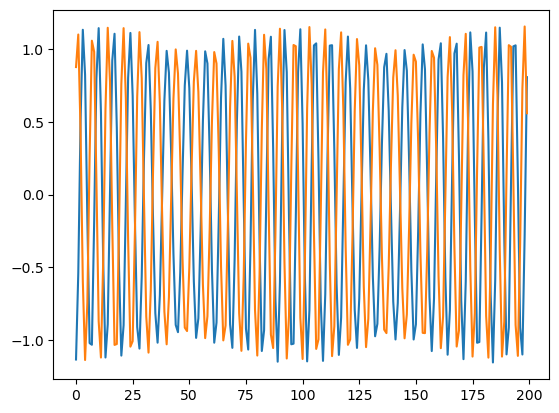

In [71]:
plt.plot(waveform[1736112-200:1736112].real)
plt.plot(waveform_res[1736112-200:1736112].real)